# 03. MATPOWER와 pandapower baseline

이제 알고리즘 내부를 알고 있으므로 baseline timing을 볼 수 있다. 여기서 비교하는 대상은 새 알고리즘들이 아니라 같은 Newton-Raphson 골격의 다른 구현이다.

- pandapower baseline: pandapower 안의 PYPOWER-derived Newton path. benchmark id는 과거 호환 때문에 `pypower-pandapower`다.
- MATPOWER default: MATLAB/MATPOWER의 AC Newton-Raphson path.
- MATPOWER LU5: 같은 MATPOWER NR에서 sparse LU 선택을 바꾼 비교점.

이 노트북부터는 `case6468rte`를 사용한다. 작은 case에서 수식은 배웠고, 이제 sparse Jacobian과 sparse linear solve 비용이 드러나는 크기가 필요하다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 1
WARMUP = 0


MATLAB/MATPOWER 실행은 repo root의 `.env` 또는 process environment를 읽는다. 이 노트북은 비밀값을 출력하지 않는다. 설정 여부만 확인한다.

기본 위치: `/workspace/gpu-powerflow-master/.env`

- online licensing: `MATLAB_LICMODE=onlinelicensing`, `MATLAB_USER_ID`, `MATLAB_PASSWORD`
- MATLAB/MATPOWER 위치: `MATLAB_BIN`, `MATPOWER_HOME`
- license server/file: `MATLAB_LICENSE_FILE` 또는 `MLM_LICENSE_FILE`


In [2]:
case = tu.load_case(TUTORIAL_CASE)
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}, pv={len(case.pv)}, pq={len(case.pq)}")
display(tu.matlab_env_summary())
display(tu.solver_path_table().iloc[:3])
print(tu.print_environment_note())


case=case6468rte, buses=6468, ybus_nnz=22598, pv=641, pq=5826


,key,status,source,secret
0,MATLAB_BIN,unset,,no
1,MATPOWER_HOME,set,process env,no
2,MATLAB_LICMODE,unset,,no
3,MATLAB_USER_ID,set,.env,yes
4,MATLAB_PASSWORD,set,.env,yes
5,MATLAB_LICENSE_FILE,unset,,no
6,MLM_LICENSE_FILE,unset,,no


,Path,Jacobian,Linear solver,Benchmark ID
0,pandapower PYPOWER-derived NR,pandapower.pypower dSbus_dV sparse block assembly,scipy.sparse.linalg.spsolve; SuperLU here unless scikits.umfpack is installed,pypower-pandapower
1,MATPOWER default,MATPOWER makeJac/dSbus_dV NR Jacobian,MATLAB default sparse solve,matpower-default
2,MATPOWER LU5,MATPOWER makeJac/dSbus_dV NR Jacobian,MATPOWER pf.nr.lin_solver='LU5',matpower-lu5


pandapower.pypower.newtonpf calls scipy.sparse.linalg.spsolve; scikits.umfpack is not installed; SciPy spsolve uses SuperLU-style path here.


먼저 Python 경로에서 Newton 내부 stage를 잰다. 이 측정은 baseline 구현의 절대값을 대변하기보다, 대형 sparse Newton에서 어디에 시간이 모이는지 보여준다. 이미 02에서 본 순서 그대로 `mismatch -> Jacobian -> linear solve -> update`가 반복된다.


converged=True, iterations=3, final_mismatch=7.732e-12


,time_ms
stage,
Linear solve,42.915
Jacobian,24.207
Voltage update,0.891
Mismatch,0.579


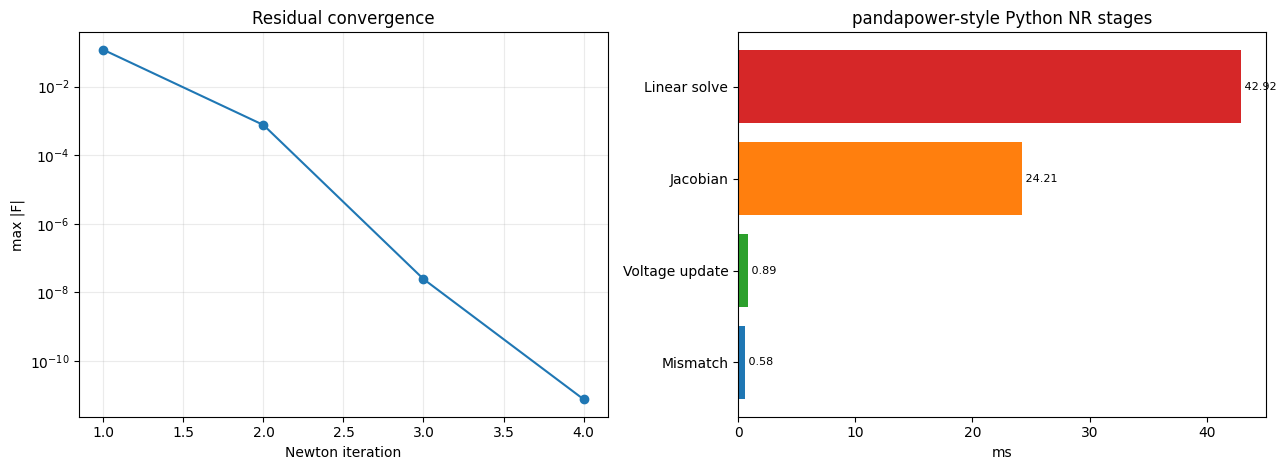

In [3]:
trace = tu.newton_trace(case, tolerance=1e-8, max_iter=50)
print(f"converged={trace.converged}, iterations={trace.iterations}, final_mismatch={trace.final_mismatch:.3e}")
display(trace.stage_totals_ms.rename('time_ms').to_frame().round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
tu.plot_newton_convergence(trace, axes[0])
tu.plot_stage_timing(trace.stage_totals_ms, axes[1], 'pandapower-style Python NR stages')
plt.tight_layout()


이제 구현별 baseline을 실행한다. 결과는 `_runs/` 아래에 남지만 git에는 포함되지 않는다. 재현성을 위해 기본은 `repeats=1`이고, 보고용 평균이 필요하면 상단의 `REPEATS`를 5 이상으로 바꾼다.


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-baseline-20260601-133914 --cases case6468rte --repeats 1 --warmup 0 --variants pypower-pandapower matpower-default matpower-lu5
[OK] elapsed=27.5s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_pypower --dataset-root /datasets/matpower --run-name tutorial-baseline-20260601-133914 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte
[pypower-pandapower][OK] case6468rte repeat=0 init_ms=260.199 solve_ms=71.303 iters=3 resid=7.732e-12
[pypower-pandapower] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-baseline-20260601-133914/pypower-pandapower/runs.csv
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_matpower --dataset-root /datasets/matpower --run-name tutorial-bas

,variant,linear_solver,initialize_ms,solve_ms,worst_residual,entrypoint
2,pypower-pandapower,scipy-spsolve,260.198974,71.302659,7.732085e-12,pandapower.pypower
0,matpower-default,default,386.202000,1039.797000,1.781664e-11,matlab-runpf
1,matpower-lu5,LU5,384.842000,1055.669000,1.203992e-11,matlab-runpf


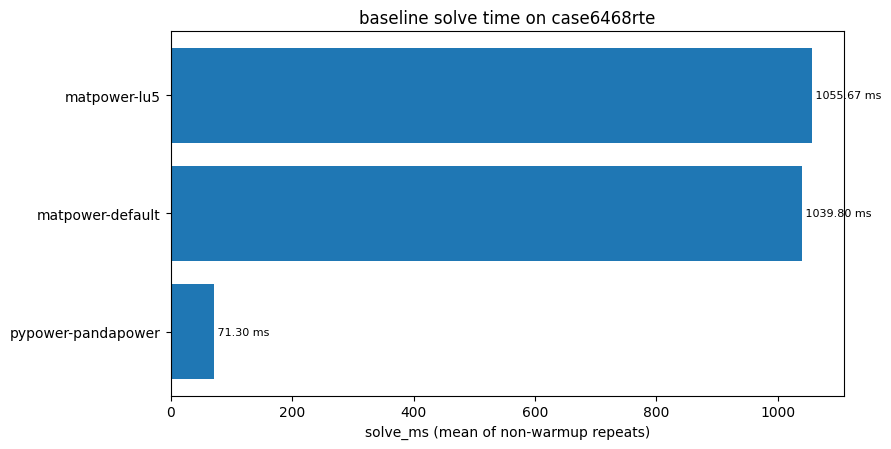

In [4]:
variants = ['pypower-pandapower', 'matpower-default', 'matpower-lu5']
if RUN_BENCHMARKS:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-baseline'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=7200,
    )
    print(tu.command_summary(command, tail_lines=18))
else:
    run_dir = tu.tutorial_output_root()

summary = tu.benchmark_result_table(run_dir)
display(summary[['variant', 'linear_solver', 'initialize_ms', 'solve_ms', 'worst_residual', 'entrypoint']])
fig, ax = plt.subplots(figsize=(9, 4.6))
tu.plot_variant_timing(summary, ax, 'baseline solve time on case6468rte')
plt.tight_layout()


해석은 단순히 “누가 빠른가”에서 끝나면 안 된다. 이후 cuPF와 비교할 때 중요한 기준은 두 가지다.

- Jacobian 계산과 sparse linear solve가 Newton 반복의 중심 비용이다.
- MATPOWER/pandapower는 같은 수학을 신뢰할 수 있는 reference로 제공하지만, 대량 반복이나 GPU batch를 목표로 설계된 runtime은 아니다.
